##Задача 1

1) Запустим  fastqc на образце SRR17307258_1

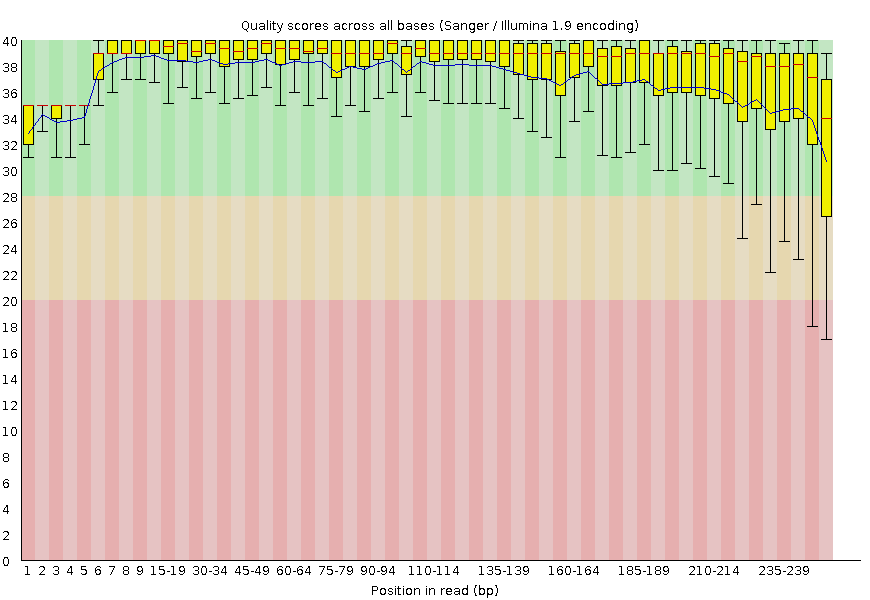

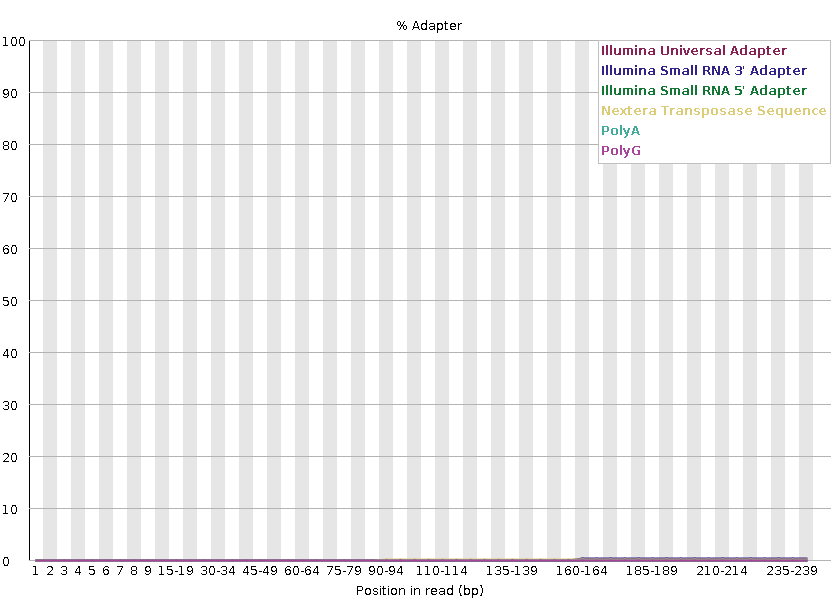

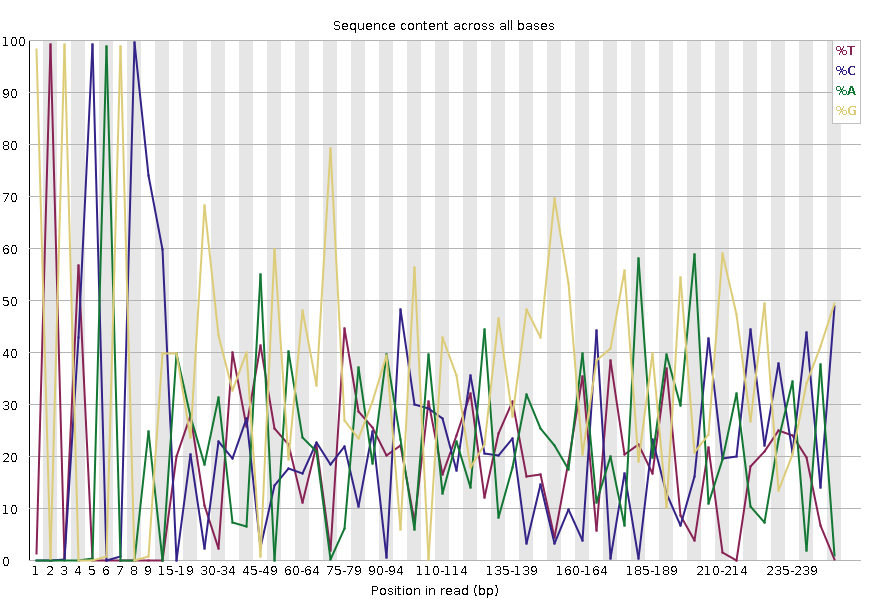

* Качество прочтений хорошее практически по всей длине рида (до 210 bp), контаминации адаптерами нет. На первых 15-19 позициях мы видим фиксированный нуклеотидный состав (это последовательность праймера 515F)

2)  Переведем данные в специальный формат .qza для
Qiime2

3) Проведем фильтрацию данных с помощью SLURM-скрипта ` qiime2_dada2.sh `

In [ ]:
# @title
#!/bin/sh
#SBATCH --job-name=qiime2_dada2_soil
#SBATCH --cpus-per-task=20
#SBATCH --mem=20gb
#SBATCH --time=01:00:00
#SBATCH --output=logs/dada2_soil.%j.log
#SBATCH --partition=AMD9554-common

HW1=/home/STUDY/FBMF/studfbmf02_05/term_2/hw_1

singularity exec \
  -H /home/STUDY/FBMF/studfbmf02_05/q2home:/home/qiime2 \
  -B /home/STUDY/FBMF \
  --env MPLCONFIGDIR=/home/STUDY/FBMF/studfbmf02_05/tmp,TMPDIR=/home/STUDY/FBMF/studfbmf02_05/tmp \
  ~/qiime2-amplicon-2024.10.sif qiime dada2 denoise-single \
    --i-demultiplexed-seqs $HW1/qza/soil_reads.qza \
    --p-trim-left 25 \
    --p-trunc-len 200 \
    --p-max-ee 3 \
    --p-n-threads 20 \
    --p-pooling-method "pseudo" \
    --p-chimera-method "consensus" \
    --p-min-fold-parent-over-abundance 4 \
    --o-table $HW1/qza/soil_ASV_table.qza \
    --o-representative-sequences $HW1/qza/soil_rep_seq.qza \
    --o-denoising-stats $HW1/qza/soil_reads.dada2.stats.qza

* В параметрах фильтрации указали `--p-trim-left 25` - это как раз удаление нашей праймерной последовательности

##Задача 2

4) Посмотрим на статистику фильтрации

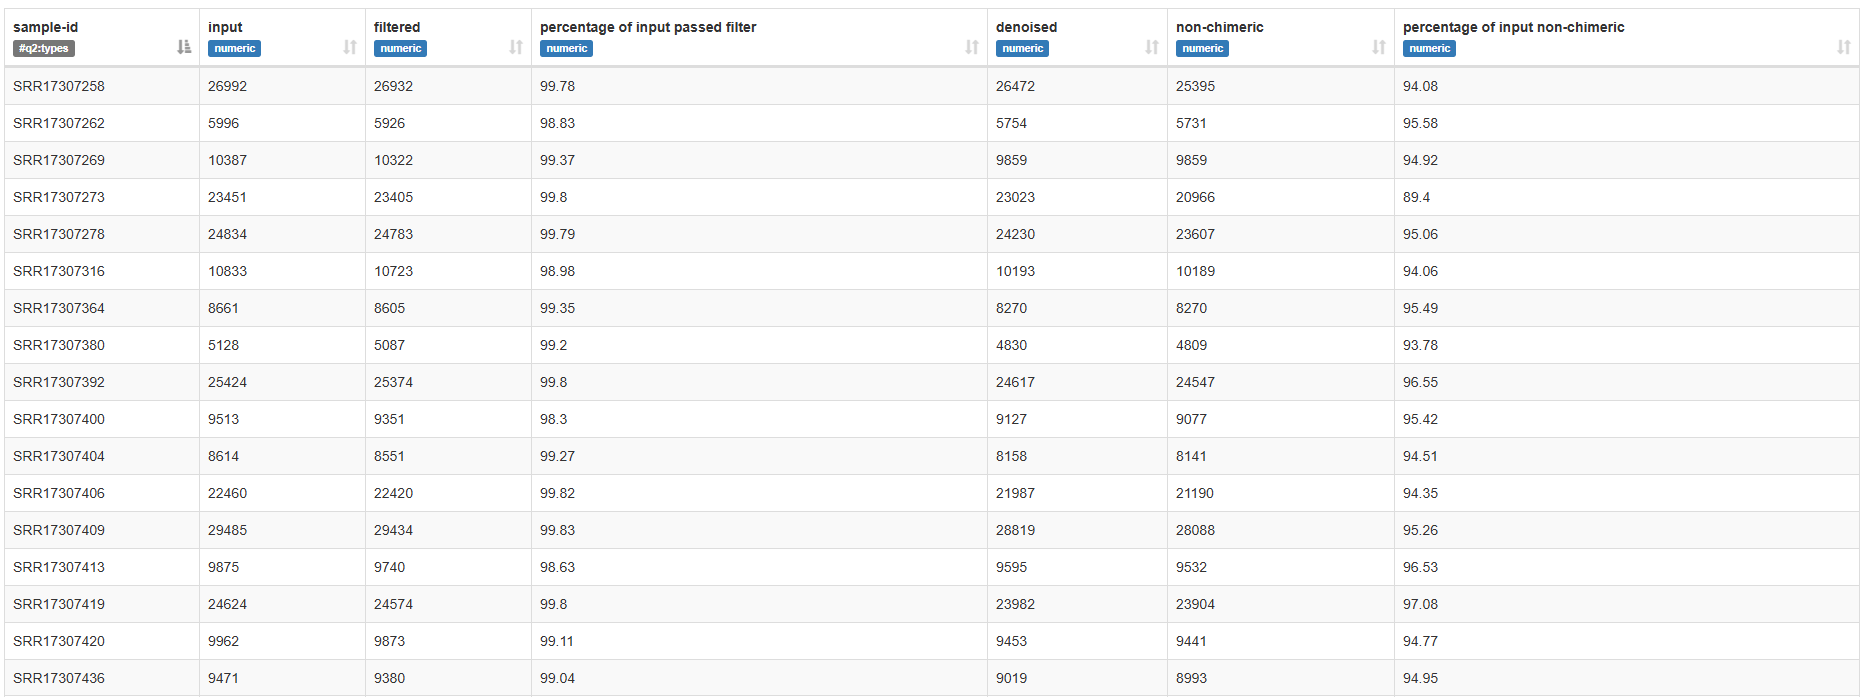

*  После прохождения всех стадий (фильтрация по качеству, денойзинг, удаление химер) в среднем сохраняется около 94-95% исходных прочтений - это говорит о хорошем качестве исходных данных
*  Самое большое число прочтений у образца SRR17307475 (45492), из которых 95,66% (43517) остались после фильтрации. Наименьшее число исходных прочтений — 5128 (образец SRR17307380), из которых сохранилось 93,78% (4809). Различие в глубине секвенирования составляет почти 9 раз, при этом сам процент прохождения фильтрации сопоставим, то есть неравномерность связана не с качеством конкретных прочтений, а с изначальными различиями в глубине секвенирования разных образцов на этапе подготовки библиотек

##Задача 3

5)  С помощью скрипта `run_taxonomy_soil.sh`  определим таксономическую принадлежность для каждого
варианта ампликона, используя уже готовый классификатор

In [ ]:
# @title
#!/bin/sh
#SBATCH --job-name=taxonomy_soil
#SBATCH --cpus-per-task=16
#SBATCH --mem=40gb
#SBATCH --time=01:00:00
#SBATCH --output=logs/taxonomy_soil.%j.log
#SBATCH --partition=AMD9554-common

HW1=/home/STUDY/FBMF/studfbmf02_05/term_2/hw_1

singularity exec \
  -H /home/STUDY/FBMF/studfbmf02_05/q2home:/home/qiime2 \
  -B /home/STUDY/FBMF \
  --env MPLCONFIGDIR=/home/STUDY/FBMF/studfbmf02_05/tmp,TMPDIR=/home/STUDY/FBMF/studfbmf02_05/tmp \
  ~/qiime2-amplicon-2024.10.sif qiime feature-classifier classify-sklearn \
    --i-classifier /home/STUDY/FBMF/bioinformatics/metagenomes/soil_hw/2022.10.backbone.v4.nb.sklearn-1.4.2.qza \
    --i-reads $HW1/qza/soil_rep_seq.qza \
    --o-classification $HW1/qza/soil_taxonomy.qza \
    --p-n-jobs 16

* Классификатор, обученный именно на V4-регионе, полностью соответствует реально анализируемым данным. В анализе используется только направление R1 + на этапе фильтрации мы обрезали по длине до 200 bp + убрали первые 25 bp праймерные участки, получаем 175 bp анализируемой последовательности V4-региона

##Задача 4

6)  Визуализируем полученную таксономию

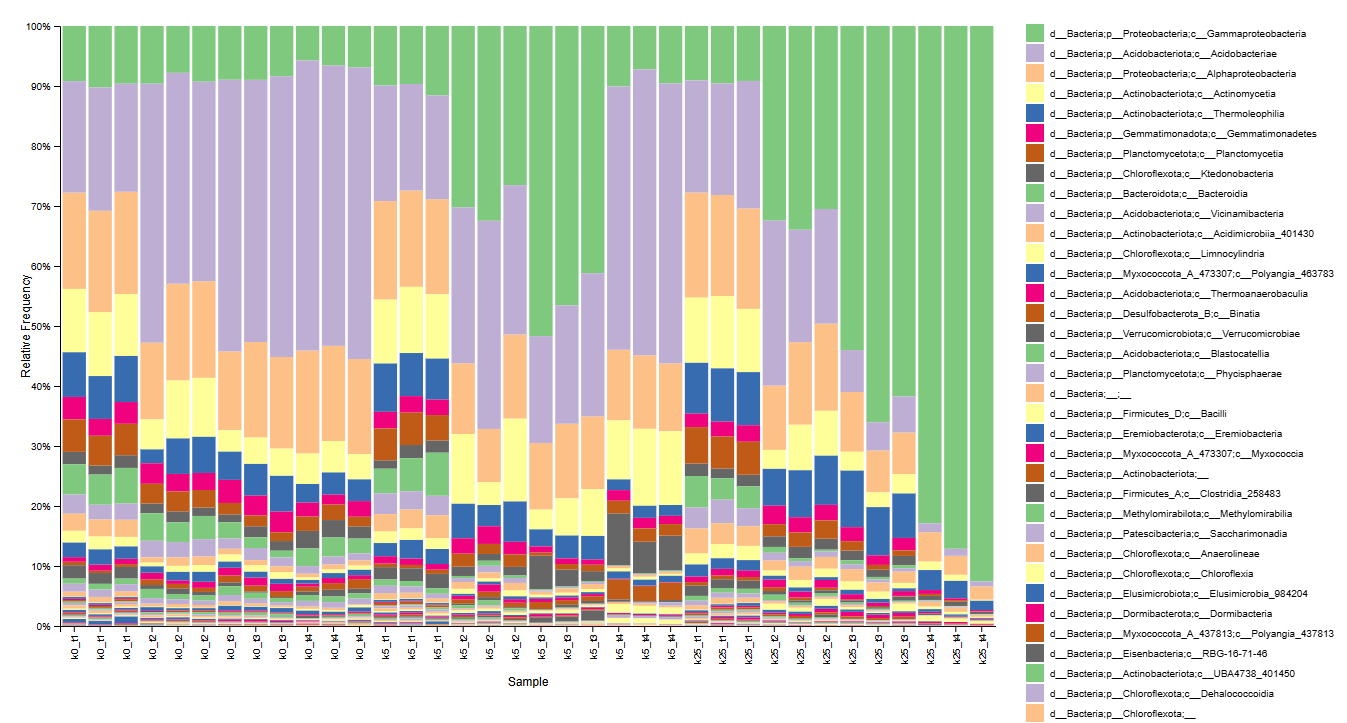

* Рассмотрим образцы с разным уровнем загрязнения керосином взятые в день 3 (t1). Заметных различий между контролем k0 и загрязнёнными образцами k5, k25 не наблюдается - за 3 дня микробное сообщество ещё не успело отреагировать на загрязнение
* Состав контроля в точке t2 немного меняется, % класса Acidobacteriae увеличивается и остается постоянным все последующие дни
* В образцах с загрязнением по прошествию времени начинает преобладать класс  Gammaproteobacteria, достигая даже 90% от всего сообщества в пробе k25_t4. Необходимо обратить внимание, что образцы почвы со слабым загрязнением на 360 день (k5_t4) не имеют ожидаемого большого % содержания Gammaproteobacteria, состав наоброт схож с контролем. Скорее всего керосин является субстрартом для этого класса бактерий, но при условии изначально малого загрязения - керосин мог быть уже почти полностью разложен к моменту t4

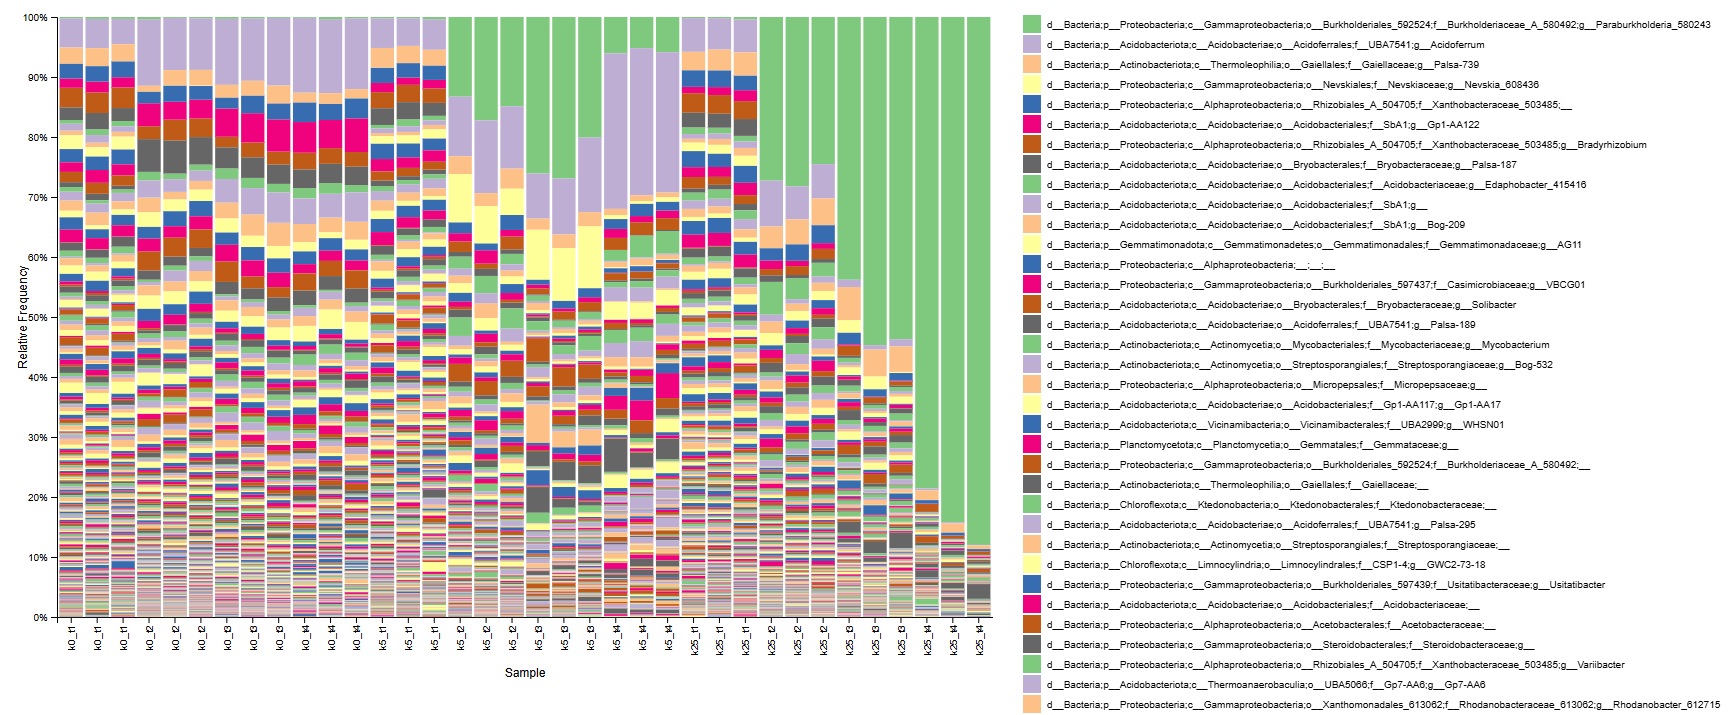

* Самый частый род в загрязнённых образцах - Paraburkholderia. Результат вполне ожидаем, тк эта группа бактерий описывается как активный деструктор углеводородов и ароматических соединений, которые составляют основу керосина. Способность метаболизировать этот источник углерода даёт таким бактериям конкурентное преимущество

##Задача 5

7) Скриптом  `run_tree_soil.sh` построим филогенетическое дерево для дальнейшей оценки альфа- и бета- разнообразия. Произведем оценку набора метрик (sampling-depth возьмем = 4809 по самому маленькому образцу)

In [ ]:
# @title
#!/bin/sh
#SBATCH --job-name=tree_soil
#SBATCH --cpus-per-task=4
#SBATCH --mem=32gb
#SBATCH --time=02:00:00
#SBATCH --output=logs/tree_soil.%j.log
#SBATCH --partition=AMD9554-common

HW1=/home/STUDY/FBMF/studfbmf02_05/term_2/hw_1

singularity exec \
  -H /home/STUDY/FBMF/studfbmf02_05/q2home:/home/qiime2 \
  -B /home/STUDY/FBMF \
  --env MPLCONFIGDIR=/home/STUDY/FBMF/studfbmf02_05/tmp,TMPDIR=/home/STUDY/FBMF/studfbmf02_05/tmp \
  ~/qiime2-amplicon-2024.10.sif qiime phylogeny align-to-tree-mafft-fasttree \
    --i-sequences $HW1/qza/soil_rep_seq.qza \
    --o-alignment $HW1/qza/aligned_soil_rep_seq.qza \
    --o-masked-alignment $HW1/qza/masked_aligned_soil_rep_seq.qza \
    --o-tree $HW1/qza/soil_unrooted_tree.qza \
    --o-rooted-tree $HW1/qza/soil_rooted_tree.qza

8)  Посмотрим на график схожести образцов

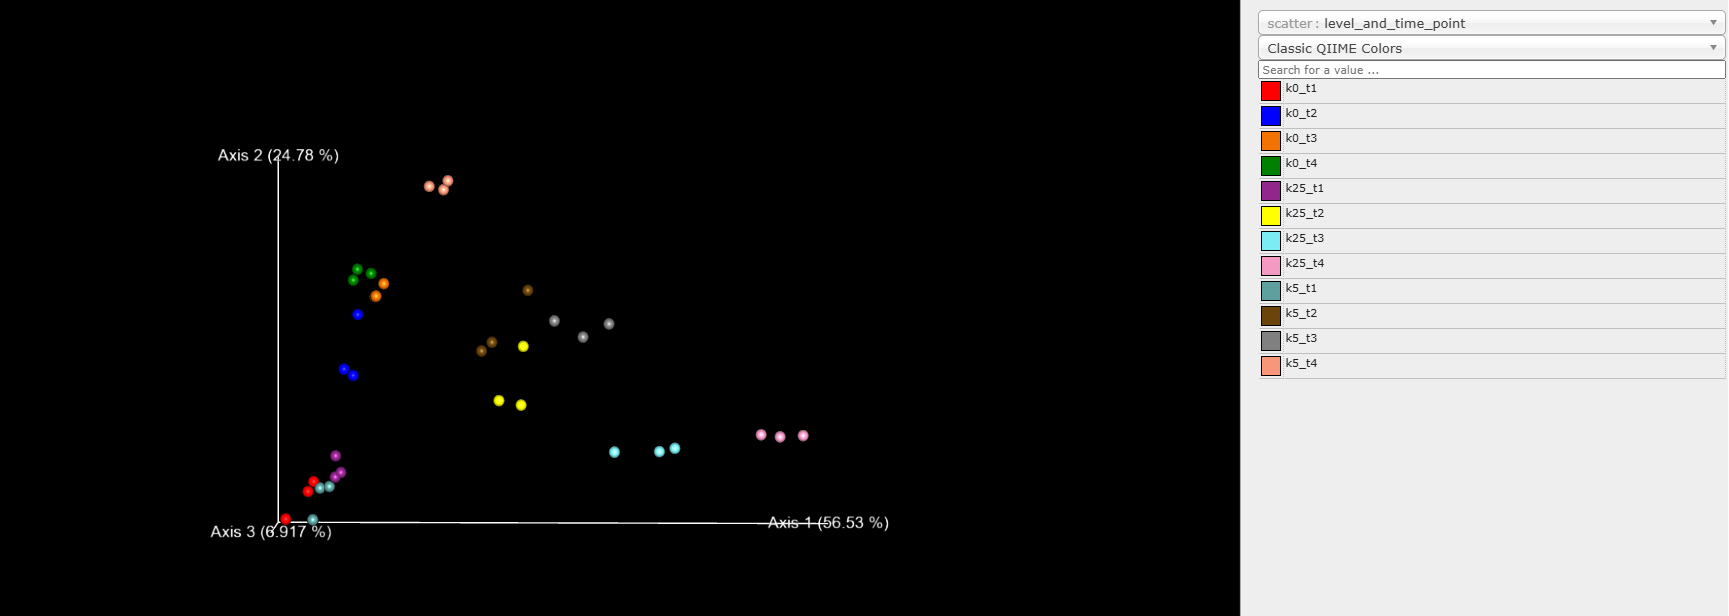

* Все образцы в t1 располагаются очень близко друг к другу, что согласуется с barplot (состав сообщества на раннем этапе ещё не успел существенно разойтись)
* Изменение положения по Axis 1 со временем:

  k0: все точки остаются в левой части графика, с небольшим сдвигом. Контроль стабилен во времени

  k5 (слабое загрязнение): точки начинают сдвигаться вправо, но на 360 день, как мы и видели в barplot, происходит частичное восстановление микробного сообщества, и оно приближается к точкам k0_t4

  k25 (сильное загрязнение): точки последовательно сдвигаются вправо без восстановления

##Задача 6

9) Посмотрим как распределён индекс Шеннона в группах образцов

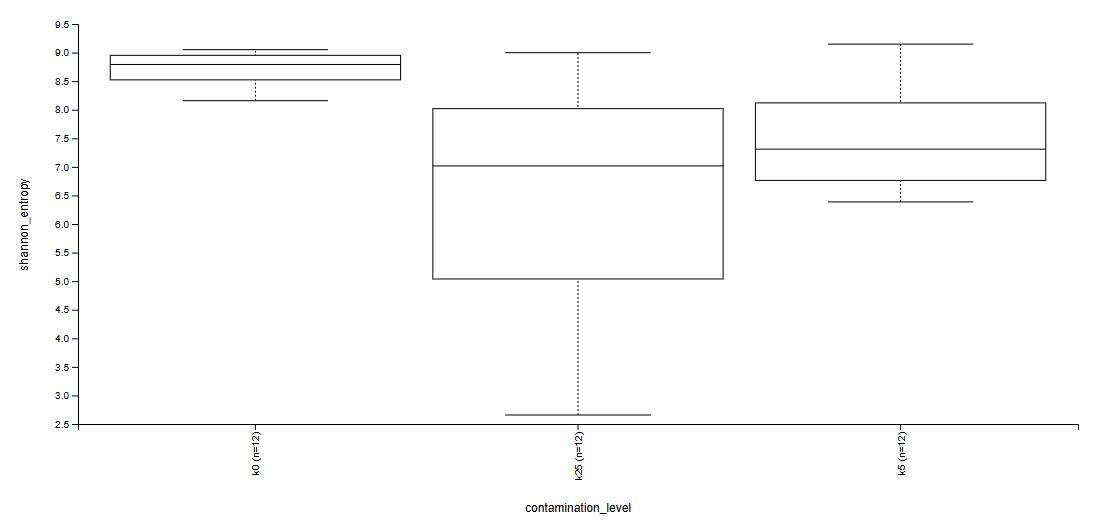

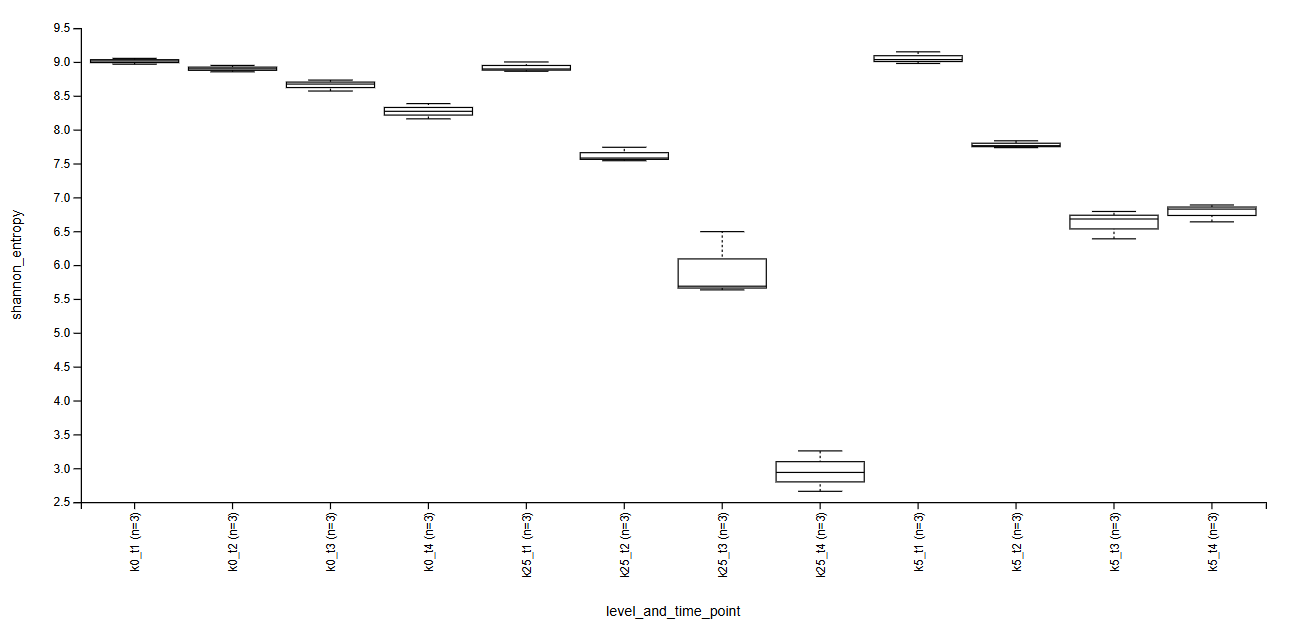

##Задача 7

k0: индекс Шеннона остаётся стабильно высоким на протяжении всего эксперимента: 8,25-9. Видим лишь очень небольшое снижение (наверное естественная динамика сообщества). В целом разнообразие остаётся высоким весь год

k5 (слабое загрязнение): Динамика совпадающая с предыдущими графиками, сначала разнообразие падает, но в конце мы видим небольшой подъем

k25 (сильное загрязнение): сильное падение разнообразия до значения 3. Такое же непрерывное изменение мы наблюдали в предыдущих задачах

##Дополнительно

В семинарской статье  в качестве основного метода использовался OTU с кластеризацией по 97% сходству (референсная база для таксономии - SILVA v128) + авторы провели проверочный анализ методом DADA2 (subOTU/ASV), который подтвердил основные выводы, полученные на OTU

На семинаре и в ДЗ мы использовали алгоритм DADA2 (ASV) с  Greengenes2 базой данных